In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [1]:
!pip install -U transformers datasets evaluate peft accelerate scikit-learn matplotlib seaborn pandas

In [2]:
import transformers
import datasets
import evaluate
import peft
import accelerate
import sklearn
import pandas
import matplotlib

print("All libraries imported successfully!")

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("PEFT:", peft.__version__)
print("Accelerate:", accelerate.__version__)

All libraries imported successfully!
Transformers: 5.17.0
Datasets: 5.0.1
PEFT: 0.21.0
Accelerate: 1.15.0


In [3]:
from datasets import load_dataset

dataset = load_dataset("lmassaron/FinancialPhraseBank")

print(dataset)

README.md:   0%|          | 0.00/2.44k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  332kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 43.2kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3872 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/484 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/484 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentiment', 'sentence', 'label'],
        num_rows: 3872
    })
    validation: Dataset({
        features: ['sentiment', 'sentence', 'label'],
        num_rows: 484
    })
    test: Dataset({
        features: ['sentiment', 'sentence', 'label'],
        num_rows: 484
    })
})


In [5]:
print(dataset["train"][0])

{'sentiment': 'neutral', 'sentence': 'The shares carry a right to dividend and other shareholder rights as from their registration with the Finnish Trade Register .', 'label': 1}


In [6]:
print(dataset["train"].column_names)

['sentiment', 'sentence', 'label']


In [7]:
print("Number of examples:", len(dataset["train"]))

Number of examples: 3872


In [9]:
from collections import Counter

labels = dataset["train"]["sentiment"]

print(Counter(labels))

Counter({'neutral': 2298, 'positive': 1091, 'negative': 483})


In [10]:
import pandas as pd

df = pd.DataFrame(dataset["train"])

print(df["sentiment"].value_counts())

sentiment
neutral     2298
positive    1091
negative     483
Name: count, dtype: int64


In [11]:
print(df["sentiment"].value_counts(normalize=True))

sentiment
neutral     0.593492
positive    0.281767
negative    0.124742
Name: proportion, dtype: float64


In [12]:
from sklearn.model_selection import train_test_split

# Convert Hugging Face dataset to pandas
df = pd.DataFrame(dataset["train"])

# First split: 80% train, 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["sentiment"]
)

# Second split: divide temporary set into 10% validation and 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["sentiment"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3097
Validation: 387
Test: 388


In [13]:
print("TRAIN")
print(train_df["sentiment"].value_counts(normalize=True))

print("\nVALIDATION")
print(val_df["sentiment"].value_counts(normalize=True))

print("\nTEST")
print(test_df["sentiment"].value_counts(normalize=True))

TRAIN
sentiment
neutral     0.593478
positive    0.281886
negative    0.124637
Name: proportion, dtype: float64

VALIDATION
sentiment
neutral     0.594315
positive    0.281654
negative    0.124031
Name: proportion, dtype: float64

TEST
sentiment
neutral     0.592784
positive    0.280928
negative    0.126289
Name: proportion, dtype: float64


In [14]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

print("Label mapping:", label2id)

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [16]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label"] = train_df["sentiment"].map(label2id)
val_df["label"] = val_df["sentiment"].map(label2id)
test_df["label"] = test_df["sentiment"].map(label2id)

print(train_df.head())

     sentiment                                           sentence  label
1278  negative  Operating profit for the 12-month period decre...      0
1021  positive  However , the proportion of the paid standing ...      2
299    neutral  The GyPSii mobile social networking applicatio...      1
2873   neutral  The agreement must be approved by the Russian ...      1
898   negative  The period-end cash and cash equivalents total...      0


In [17]:
print("Missing labels:")
print("Train:", train_df["label"].isna().sum())
print("Validation:", val_df["label"].isna().sum())
print("Test:", test_df["label"].isna().sum())

Missing labels:
Train: 0
Validation: 0
Test: 0


In [18]:
from transformers import AutoTokenizer

model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [19]:
example_text = train_df["sentence"].iloc[0]

print("Original:")
print(example_text)

print("\nTokens:")
print(tokenizer.tokenize(example_text))

Original:
Operating profit for the 12-month period decreased from EUR28 .2 m while net turnover increased from EUR313 .42 m , as compared to the financial year 2004 .

Tokens:
['operating', 'profit', 'for', 'the', '12', '-', 'month', 'period', 'decreased', 'from', 'eu', '##r', '##28', '.', '2', 'm', 'while', 'net', 'turnover', 'increased', 'from', 'eu', '##r', '##31', '##3', '.', '42', 'm', ',', 'as', 'compared', 'to', 'the', 'financial', 'year', '2004', '.']


In [20]:
encoded = tokenizer(
    example_text,
    padding="max_length",
    truncation=True,
    max_length=128
)

print(encoded)

{'input_ids': [101, 4082, 5618, 2005, 1996, 2260, 1011, 3204, 2558, 10548, 2013, 7327, 2099, 22407, 1012, 1016, 1049, 2096, 5658, 20991, 3445, 2013, 7327, 2099, 21486, 2509, 1012, 4413, 1049, 1010, 2004, 4102, 2000, 1996, 3361, 2095, 2432, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [21]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["sentence", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["sentence", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["sentence", "label"]],
    preserve_index=False
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['sentence', 'label'],
    num_rows: 3097
})
Dataset({
    features: ['sentence', 'label'],
    num_rows: 387
})
Dataset({
    features: ['sentence', 'label'],
    num_rows: 388
})


In [25]:
def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [26]:
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization complete!")

Map:   0%|          | 0/3097 [00:00<?, ? examples/s]

Map:   0%|          | 0/387 [00:00<?, ? examples/s]

Map:   0%|          | 0/388 [00:00<?, ? examples/s]

Tokenization complete!


In [27]:
print(train_tokenized[0])

{'sentence': 'Operating profit for the 12-month period decreased from EUR28 .2 m while net turnover increased from EUR313 .42 m , as compared to the financial year 2004 .', 'label': 0, 'input_ids': [101, 4082, 5618, 2005, 1996, 2260, 1011, 3204, 2558, 10548, 2013, 7327, 2099, 22407, 1012, 1016, 1049, 2096, 5658, 20991, 3445, 2013, 7327, 2099, 21486, 2509, 1012, 4413, 1049, 1010, 2004, 4102, 2000, 1996, 3361, 2095, 2432, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [28]:
import numpy as np

lengths = [
    len(tokenizer.encode(
        text,
        truncation=False
    ))
    for text in train_df["sentence"]
]

print("Maximum token length:", max(lengths))
print("Average token length:", np.mean(lengths))
print("95th percentile:", np.percentile(lengths, 95))

Maximum token length: 109
Average token length: 30.60122699386503
95th percentile: 57.0


In [29]:
train_tokenized = train_tokenized.remove_columns(["sentence"])
val_tokenized = val_tokenized.remove_columns(["sentence"])
test_tokenized = test_tokenized.remove_columns(["sentence"])

print(train_tokenized.column_names)

['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [30]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print("FinBERT loaded successfully!")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded successfully!


In [31]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [32]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 109,484,547
Trainable parameters: 109,484,547


In [33]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Model running on:", device)

Model running on: cuda


In [34]:
text = test_df["sentence"].iloc[0]

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=128
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

with torch.no_grad():
    outputs = model(**inputs)

print("Logits:", outputs.logits)

Logits: tensor([[ 2.0412, -1.8202, -1.5361]], device='cuda:0')


In [35]:
import torch

probabilities = torch.softmax(outputs.logits, dim=-1)

print(probabilities)

tensor([[0.9533, 0.0201, 0.0266]], device='cuda:0')


In [36]:
prediction = torch.argmax(probabilities, dim=-1).item()

print("Predicted:", id2label[prediction])
print("Actual:", test_df["sentiment"].iloc[0])

Predicted: negative
Actual: positive


In [37]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_tokenized,
    batch_size=16,
    shuffle=False
)

print("Test batches:", len(test_loader))

Test batches: 25


In [39]:
from transformers import DataCollatorWithPadding
from torch.utils.data import DataLoader

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

test_loader = DataLoader(
    test_tokenized,
    batch_size=16,
    shuffle=False,
    collate_fn=data_collator
)

print("Test batches:", len(test_loader))

Test batches: 25


In [40]:
batch = next(iter(test_loader))

print(type(batch))
print(batch.keys())

for key, value in batch.items():
    print(key, type(value), value.shape if hasattr(value, "shape") else "no shape")

<class 'transformers.tokenization_utils_base.BatchEncoding'>
KeysView({'input_ids': tensor([[  101,  6599,  3473,  ...,     0,     0,     0],
        [  101,  6983, 10958,  ...,     0,     0,     0],
        [  101,  4597,  2041,  ...,     0,     0,     0],
        ...,
        [  101, 12849,  2638,  ...,     0,     0,     0],
        [  101,  6983,  5211,  ...,     0,     0,     0],
        [  101,  1996,  2194,  ...,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([2, 2, 1, 2, 2, 1, 1, 0, 1, 2, 1, 1, 0, 1, 0, 1])})
input_ids 

In [42]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        # Transformers collator provides the target as "labels"
        labels = batch["labels"].to(device)

        # Everything except labels is model input
        inputs = {
            key: value.to(device)
            for key, value in batch.items()
            if key != "labels"
        }

        outputs = model(**inputs)

        predictions = torch.argmax(
            outputs.logits,
            dim=-1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("Predictions:", len(all_predictions))
print("Labels:", len(all_labels))

Predictions: 388
Labels: 388


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

baseline_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

baseline_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

baseline_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

baseline_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"Macro-F1:  {baseline_f1:.4f}")

Accuracy:  0.0593
Precision: 0.0878
Recall:    0.0516
Macro-F1:  0.0527


In [44]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative       0.01      0.02      0.01        49
     neutral       0.22      0.06      0.09       230
    positive       0.04      0.07      0.05       109

    accuracy                           0.06       388
   macro avg       0.09      0.05      0.05       388
weighted avg       0.14      0.06      0.07       388



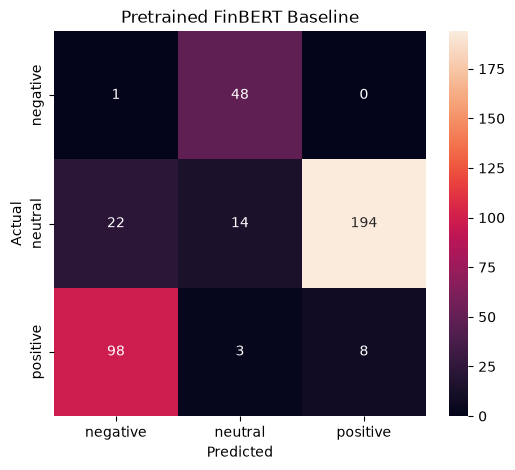

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Pretrained FinBERT Baseline")

plt.show()

In [46]:
import json

baseline_results = {
    "model": "FinBERT pretrained",
    "accuracy": float(baseline_accuracy),
    "precision_macro": float(baseline_precision),
    "recall_macro": float(baseline_recall),
    "f1_macro": float(baseline_f1)
}

with open("baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=4)

print("Baseline results saved:")
print(json.dumps(baseline_results, indent=4))

Baseline results saved:
{
    "model": "FinBERT pretrained",
    "accuracy": 0.059278350515463915,
    "precision_macro": 0.08775101286352412,
    "recall_macro": 0.05155740796518049,
    "f1_macro": 0.05270896848575388
}


In [47]:
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

print("PEFT LoRA components loaded successfully!")

PEFT LoRA components loaded successfully!


In [48]:
from transformers import AutoModelForSequenceClassification

lora_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

lora_model = lora_model.to(device)

print("Fresh FinBERT model loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Fresh FinBERT model loaded.


In [49]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none"
)

print(lora_config)

LoraConfig(task_type=<TaskType.SEQ_CLS: 'SEQ_CLS'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.21.0', base_model_name_or_path=None, revision=None, inference_mode=False, r=8, target_modules={'query', 'value'}, exclude_modules=None, lora_alpha=16, lora_dropout=0.1, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, kasa_config=None, ensure_weight_tying=False)


In [50]:
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none"
)

print(lora_config)

LoraConfig(task_type=<TaskType.SEQ_CLS: 'SEQ_CLS'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.21.0', base_model_name_or_path=None, revision=None, inference_mode=False, r=8, target_modules={'query', 'value'}, exclude_modules=None, lora_alpha=16, lora_dropout=0.1, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, kasa_config=None, ensure_weight_tying=False)


In [52]:
!pip install -U "torchao>=0.17.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 36.3 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [1]:
import torch
import torchao
import peft

print("PyTorch:", torch.__version__)
print("TorchAO:", torchao.__version__)
print("PEFT:", peft.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
TorchAO: 0.18.0
PEFT: 0.21.0
CUDA available: True


In [2]:
print("lora_config" in globals())
print("lora_model" in globals())

False
False


In [3]:
from transformers import AutoModelForSequenceClassification

model_name = "ProsusAI/finbert"

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lora_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

lora_model = lora_model.to(device)

print("Fresh FinBERT model loaded.")
print("Model device:", next(lora_model.parameters()).device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Fresh FinBERT model loaded.
Model device: cuda:0


In [4]:
from peft import LoraConfig, TaskType

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none"
)

print("LoRA configuration created successfully!")

LoRA configuration created successfully!


In [5]:
from peft import get_peft_model

lora_model = get_peft_model(
    lora_model,
    lora_config
)

print("LoRA applied successfully!")

LoRA applied successfully!


In [6]:
lora_model.print_trainable_parameters()

trainable params: 297,219 || all params: 109,781,766 || trainable%: 0.2707


In [7]:
from transformers import TrainingArguments, Trainer
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision_macro": precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "f1_macro": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    }

training_args = TrainingArguments(
    output_dir="./finbert-lora-results",

    learning_rate=2e-4,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=20,

    save_total_limit=2,

    fp16=True,

    report_to="none"
)

print("Training configuration created successfully!")

Training configuration created successfully!


In [8]:
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

NameError: name 'train_tokenized' is not defined

In [9]:
print("train_df" in globals())
print("val_df" in globals())
print("test_df" in globals())
print("tokenizer" in globals())

False
False
False
False


In [10]:
from datasets import load_dataset

dataset = load_dataset("lmassaron/FinancialPhraseBank")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['sentiment', 'sentence', 'label'],
        num_rows: 3872
    })
    validation: Dataset({
        features: ['sentiment', 'sentence', 'label'],
        num_rows: 484
    })
    test: Dataset({
        features: ['sentiment', 'sentence', 'label'],
        num_rows: 484
    })
})


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.DataFrame(dataset["train"])

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["sentiment"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["sentiment"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Train: 3097
Validation: 387
Test: 388
Total: 3872


In [12]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label"] = train_df["sentiment"].map(label2id)
val_df["label"] = val_df["sentiment"].map(label2id)
test_df["label"] = test_df["sentiment"].map(label2id)

print("Missing labels:")
print("Train:", train_df["label"].isna().sum())
print("Validation:", val_df["label"].isna().sum())
print("Test:", test_df["label"].isna().sum())

Missing labels:
Train: 0
Validation: 0
Test: 0


In [14]:
from transformers import AutoTokenizer

model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


In [15]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["sentence", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["sentence", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["sentence", "label"]],
    preserve_index=False
)

print("Datasets created successfully!")

Datasets created successfully!


In [16]:
def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed successfully!")

Map:   0%|          | 0/3097 [00:00<?, ? examples/s]

Map:   0%|          | 0/387 [00:00<?, ? examples/s]

Map:   0%|          | 0/388 [00:00<?, ? examples/s]

Tokenization completed successfully!


In [17]:
train_tokenized = train_tokenized.remove_columns(["sentence"])
val_tokenized = val_tokenized.remove_columns(["sentence"])
test_tokenized = test_tokenized.remove_columns(["sentence"])

print("Raw sentence columns removed.")
print(train_tokenized.column_names)

Raw sentence columns removed.
['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [18]:
train_tokenized = train_tokenized.rename_column("label", "labels")
val_tokenized = val_tokenized.rename_column("label", "labels")
test_tokenized = test_tokenized.rename_column("label", "labels")

print("Train columns:", train_tokenized.column_names)
print("Validation columns:", val_tokenized.column_names)
print("Test columns:", test_tokenized.column_names)

Train columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Validation columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Test columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [20]:
from transformers import Trainer

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Metric functions loaded successfully!")

Metric functions loaded successfully!


In [24]:
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision_macro": precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "f1_macro": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    }

print("compute_metrics restored successfully!")

compute_metrics restored successfully!


In [25]:
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

print("Trainer recreated successfully!")

Trainer recreated successfully!


In [26]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.229600,0.309953,0.894057,0.871049,0.916719,0.890246
2,0.247049,0.274362,0.912145,0.891057,0.918151,0.903653
3,0.168571,0.280444,0.906977,0.886095,0.915252,0.899474


In [28]:
print(train_result)

TrainOutput(global_step=582, training_loss=0.21606879832408682, metrics={'train_runtime': 60.4309, 'train_samples_per_second': 153.746, 'train_steps_per_second': 9.631, 'total_flos': 613267493635584.0, 'train_loss': 0.21606879832408682, 'epoch': 3.0})


In [29]:
print("Training completed.")
print("Final training loss:", train_result.training_loss)
print("Training steps:", train_result.global_step)

Training completed.
Final training loss: 0.21606879832408682
Training steps: 582


In [31]:
test_results = trainer.evaluate(
    eval_dataset=test_tokenized
)

print("Test evaluation completed!")
print(test_results)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,0.201074,0.362500,0.873711,0.842110,0.905935,0.867951


Test evaluation completed!
{'eval_loss': 0.36249983310699463, 'eval_accuracy': 0.8737113402061856, 'eval_precision_macro': 0.842110263485365, 'eval_recall_macro': 0.9059349467748806, 'eval_f1_macro': 0.8679508762842096}


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,0.201074,0.362500,0.873711,0.842110,0.905935,0.867951


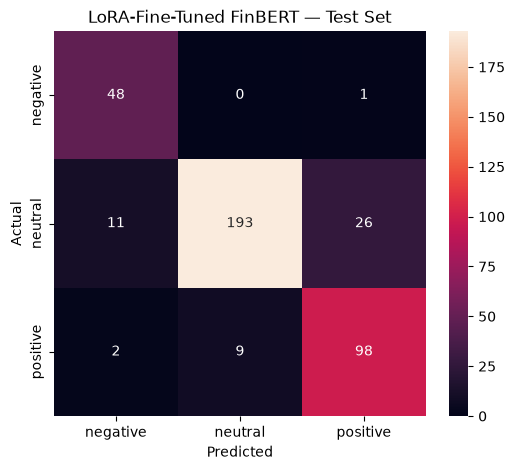

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

predictions_output = trainer.predict(test_tokenized)

test_predictions = np.argmax(
    predictions_output.predictions,
    axis=-1
)

test_labels = predictions_output.label_ids

cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LoRA-Fine-Tuned FinBERT — Test Set")
plt.show()

In [33]:
import json

lora_results = {
    "model": "FinBERT + LoRA",
    "dataset": "Financial PhraseBank",
    "train_samples": 3097,
    "validation_samples": 387,
    "test_samples": 388,
    "epochs": 3,
    "training_steps": 582,
    "final_training_loss": float(train_result.training_loss),
    "test_loss": float(test_results["eval_loss"]),
    "accuracy": float(test_results["eval_accuracy"]),
    "precision_macro": float(test_results["eval_precision_macro"]),
    "recall_macro": float(test_results["eval_recall_macro"]),
    "f1_macro": float(test_results["eval_f1_macro"]),
    "confusion_matrix": cm.tolist()
}

with open("lora_results.json", "w") as f:
    json.dump(lora_results, f, indent=4)

print(json.dumps(lora_results, indent=4))

{
    "model": "FinBERT + LoRA",
    "dataset": "Financial PhraseBank",
    "train_samples": 3097,
    "validation_samples": 387,
    "test_samples": 388,
    "epochs": 3,
    "training_steps": 582,
    "final_training_loss": 0.21606879832408682,
    "test_loss": 0.36249983310699463,
    "accuracy": 0.8737113402061856,
    "precision_macro": 0.842110263485365,
    "recall_macro": 0.9059349467748806,
    "f1_macro": 0.8679508762842096,
    "confusion_matrix": [
        [
            48,
            0,
            1
        ],
        [
            11,
            193,
            26
        ],
        [
            2,
            9,
            98
        ]
    ]
}


In [34]:
import os
import json

print("Baseline file exists:", os.path.exists("baseline_results.json"))

if os.path.exists("baseline_results.json"):
    with open("baseline_results.json", "r") as f:
        baseline_results = json.load(f)

    print(json.dumps(baseline_results, indent=4))

Baseline file exists: True
{
    "model": "FinBERT pretrained",
    "accuracy": 0.059278350515463915,
    "precision_macro": 0.08775101286352412,
    "recall_macro": 0.05155740796518049,
    "f1_macro": 0.05270896848575388
}


In [35]:
print("PRETRAINED FINBERT BASELINE")
print("-" * 35)

for key, value in baseline_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nLORA-FINETUNED FINBERT")
print("-" * 35)

for key, value in lora_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

PRETRAINED FINBERT BASELINE
-----------------------------------
model: FinBERT pretrained
accuracy: 0.0593
precision_macro: 0.0878
recall_macro: 0.0516
f1_macro: 0.0527

LORA-FINETUNED FINBERT
-----------------------------------
model: FinBERT + LoRA
dataset: Financial PhraseBank
train_samples: 3097
validation_samples: 387
test_samples: 388
epochs: 3
training_steps: 582
final_training_loss: 0.2161
test_loss: 0.3625
accuracy: 0.8737
precision_macro: 0.8421
recall_macro: 0.9059
f1_macro: 0.8680
confusion_matrix: [[48, 0, 1], [11, 193, 26], [2, 9, 98]]


In [36]:
print("Baseline accuracy:", baseline_results["accuracy"])
print("LoRA accuracy:", lora_results["accuracy"])

print("\nBaseline predictions sample:")
print(all_predictions[:20])

print("\nActual labels sample:")
print(all_labels[:20])

Baseline accuracy: 0.059278350515463915
LoRA accuracy: 0.8737113402061856

Baseline predictions sample:


NameError: name 'all_predictions' is not defined

In [37]:
from transformers import AutoModelForSequenceClassification
import torch

baseline_model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

baseline_model = baseline_model.to(device)
baseline_model.eval()

print("Fresh pretrained FinBERT loaded.")
print("Device:", next(baseline_model.parameters()).device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Fresh pretrained FinBERT loaded.
Device: cuda:0


In [38]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

baseline_test_loader = DataLoader(
    test_tokenized,
    batch_size=16,
    shuffle=False,
    collate_fn=data_collator
)

print("Test batches:", len(baseline_test_loader))

Test batches: 25


In [39]:
baseline_predictions = []
baseline_labels = []

with torch.no_grad():

    for batch in baseline_test_loader:

        labels = batch["labels"].to(device)

        inputs = {
            key: value.to(device)
            for key, value in batch.items()
            if key != "labels"
        }

        outputs = baseline_model(**inputs)

        predictions = torch.argmax(
            outputs.logits,
            dim=-1
        )

        baseline_predictions.extend(
            predictions.cpu().numpy()
        )

        baseline_labels.extend(
            labels.cpu().numpy()
        )

print("Baseline predictions:", len(baseline_predictions))
print("Baseline labels:", len(baseline_labels))

Baseline predictions: 388
Baseline labels: 388


In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

baseline_accuracy_verified = accuracy_score(
    baseline_labels,
    baseline_predictions
)

baseline_precision_verified = precision_score(
    baseline_labels,
    baseline_predictions,
    average="macro",
    zero_division=0
)

baseline_recall_verified = recall_score(
    baseline_labels,
    baseline_predictions,
    average="macro",
    zero_division=0
)

baseline_f1_verified = f1_score(
    baseline_labels,
    baseline_predictions,
    average="macro",
    zero_division=0
)

print(f"Accuracy:       {baseline_accuracy_verified:.4f}")
print(f"Precision:      {baseline_precision_verified:.4f}")
print(f"Recall:         {baseline_recall_verified:.4f}")
print(f"Macro-F1:       {baseline_f1_verified:.4f}")

Accuracy:       0.0593
Precision:      0.0878
Recall:         0.0516
Macro-F1:       0.0527


In [41]:
print(
    classification_report(
        baseline_labels,
        baseline_predictions,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative       0.01      0.02      0.01        49
     neutral       0.22      0.06      0.09       230
    positive       0.04      0.07      0.05       109

    accuracy                           0.06       388
   macro avg       0.09      0.05      0.05       388
weighted avg       0.14      0.06      0.07       388



In [42]:
print("Pretrained FinBERT label mapping:")
print(baseline_model.config.id2label)
print(baseline_model.config.label2id)

Pretrained FinBERT label mapping:
{0: 'negative', 1: 'neutral', 2: 'positive'}
{'negative': 0, 'neutral': 1, 'positive': 2}


In [43]:
from transformers import AutoModelForSequenceClassification

baseline_model_clean = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert"
)

baseline_model_clean = baseline_model_clean.to(device)
baseline_model_clean.eval()

print("Clean pretrained FinBERT loaded.")
print("Labels:", baseline_model_clean.config.id2label)
print("Device:", next(baseline_model_clean.parameters()).device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Clean pretrained FinBERT loaded.
Labels: {0: 'positive', 1: 'negative', 2: 'neutral'}
Device: cuda:0


In [44]:
clean_predictions = []
clean_labels = []

with torch.no_grad():

    for batch in baseline_test_loader:

        labels = batch["labels"].to(device)

        inputs = {
            key: value.to(device)
            for key, value in batch.items()
            if key != "labels"
        }

        outputs = baseline_model_clean(**inputs)

        predictions = torch.argmax(
            outputs.logits,
            dim=-1
        )

        clean_predictions.extend(
            predictions.cpu().numpy()
        )

        clean_labels.extend(
            labels.cpu().numpy()
        )

print("Predictions:", len(clean_predictions))
print("Labels:", len(clean_labels))

Predictions: 388
Labels: 388


In [45]:
clean_accuracy = accuracy_score(
    clean_labels,
    clean_predictions
)

print(f"Clean pretrained FinBERT accuracy: {clean_accuracy:.4f}")

Clean pretrained FinBERT accuracy: 0.0593


In [46]:
for i in range(15):
    print(
        f"{i}: "
        f"Actual={id2label[clean_labels[i]]} | "
        f"Predicted={id2label[clean_predictions[i]]} | "
        f"Text={test_df.iloc[i]['sentence']}"
    )

0: Actual=positive | Predicted=negative | Text=Revenue grew by 2 percent to  x20ac 580 million $ 743 million , from  x20ac 569 million .
1: Actual=positive | Predicted=negative | Text=Finnish Raute Precision has won large glass batch plant and mortar plant orders from Mexico and the US .
2: Actual=neutral | Predicted=positive | Text=LIGHTS OUT Before curfew , curl up with the latest bestseller and treat your eyes to the perfect reading light from Luceplan .
3: Actual=positive | Predicted=negative | Text=Pretax profit rose to EUR 0.6 mn from EUR 0.4 mn in the corresponding period in 2005 .
4: Actual=positive | Predicted=negative | Text=Both operating profit and net sales for the 12-month period increased , respectively from EUR20 .8 m and EUR177 .7 m , as compared to the financial year 2004 .
5: Actual=neutral | Predicted=positive | Text=Our key geographical markets are Europe , Russian Federation , Middle-East , South-Africa and Japan .
6: Actual=neutral | Predicted=neutral | Text=Finn

In [47]:
print("CLEAN MODEL LABEL MAPPING:")
print(baseline_model_clean.config.id2label)
print(baseline_model_clean.config.label2id)

CLEAN MODEL LABEL MAPPING:
{0: 'positive', 1: 'negative', 2: 'neutral'}
{'positive': 0, 'negative': 1, 'neutral': 2}


In [48]:
# FinBERT checkpoint:
# 0 = positive
# 1 = negative
# 2 = neutral

# Our dataset:
# 0 = negative
# 1 = neutral
# 2 = positive

finbert_to_dataset = {
    0: 2,  # positive -> 2
    1: 0,  # negative -> 0
    2: 1   # neutral  -> 1
}

corrected_baseline_predictions = [
    finbert_to_dataset[pred]
    for pred in clean_predictions
]

corrected_baseline_accuracy = accuracy_score(
    clean_labels,
    corrected_baseline_predictions
)

corrected_baseline_precision = precision_score(
    clean_labels,
    corrected_baseline_predictions,
    average="macro",
    zero_division=0
)

corrected_baseline_recall = recall_score(
    clean_labels,
    corrected_baseline_predictions,
    average="macro",
    zero_division=0
)

corrected_baseline_f1 = f1_score(
    clean_labels,
    corrected_baseline_predictions,
    average="macro",
    zero_division=0
)

print(f"Accuracy:       {corrected_baseline_accuracy:.4f}")
print(f"Precision:      {corrected_baseline_precision:.4f}")
print(f"Recall:         {corrected_baseline_recall:.4f}")
print(f"Macro-F1:       {corrected_baseline_f1:.4f}")

Accuracy:       0.8763
Precision:      0.8363
Recall:         0.9074
Macro-F1:       0.8641


In [49]:
corrected_baseline_results = {
    "model": "FinBERT pretrained",
    "dataset": "Financial PhraseBank",
    "test_samples": 388,
    "accuracy": float(corrected_baseline_accuracy),
    "precision_macro": float(corrected_baseline_precision),
    "recall_macro": float(corrected_baseline_recall),
    "f1_macro": float(corrected_baseline_f1)
}

with open("baseline_results.json", "w") as f:
    json.dump(corrected_baseline_results, f, indent=4)

print(json.dumps(corrected_baseline_results, indent=4))

{
    "model": "FinBERT pretrained",
    "dataset": "Financial PhraseBank",
    "test_samples": 388,
    "accuracy": 0.8762886597938144,
    "precision_macro": 0.8362583111457998,
    "recall_macro": 0.9073842221371996,
    "f1_macro": 0.8641424414498404
}


In [50]:
import json

comparison = {
    "dataset": "Financial PhraseBank",
    "test_samples": 388,
    "models": {
        "FinBERT pretrained": {
            "accuracy": 0.8762886597938144,
            "precision_macro": 0.8362583111457998,
            "recall_macro": 0.9073842221371996,
            "f1_macro": 0.8641424414498404
        },
        "FinBERT + LoRA": {
            "accuracy": 0.8737113402061856,
            "precision_macro": 0.842110263485365,
            "recall_macro": 0.9059349467748806,
            "f1_macro": 0.8679508762842096
        }
    }
}

with open("model_comparison.json", "w") as f:
    json.dump(comparison, f, indent=4)

print(json.dumps(comparison, indent=4))

{
    "dataset": "Financial PhraseBank",
    "test_samples": 388,
    "models": {
        "FinBERT pretrained": {
            "accuracy": 0.8762886597938144,
            "precision_macro": 0.8362583111457998,
            "recall_macro": 0.9073842221371996,
            "f1_macro": 0.8641424414498404
        },
        "FinBERT + LoRA": {
            "accuracy": 0.8737113402061856,
            "precision_macro": 0.842110263485365,
            "recall_macro": 0.9059349467748806,
            "f1_macro": 0.8679508762842096
        }
    }
}


In [51]:
import pandas as pd

comparison_df = pd.DataFrame([
    {
        "model": "FinBERT pretrained",
        "accuracy": 0.8762886597938144,
        "precision_macro": 0.8362583111457998,
        "recall_macro": 0.9073842221371996,
        "f1_macro": 0.8641424414498404
    },
    {
        "model": "FinBERT + LoRA",
        "accuracy": 0.8737113402061856,
        "precision_macro": 0.842110263485365,
        "recall_macro": 0.9059349467748806,
        "f1_macro": 0.8679508762842096
    }
])

comparison_df.to_csv("model_comparison.csv", index=False)

display(comparison_df)

,model,accuracy,precision_macro,recall_macro,f1_macro
0,FinBERT pretrained,0.876289,0.836258,0.907384,0.864142
1,FinBERT + LoRA,0.873711,0.842110,0.905935,0.867951


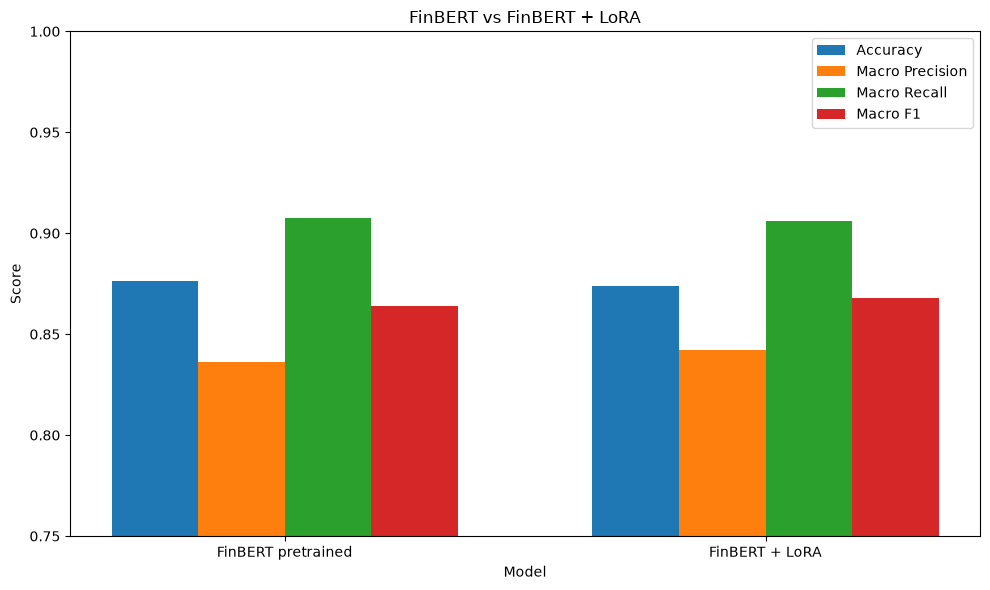

In [52]:
import matplotlib.pyplot as plt
import numpy as np

models = ["FinBERT pretrained", "FinBERT + LoRA"]

accuracy = [0.8762886597938144, 0.8737113402061856]
precision = [0.8362583111457998, 0.842110263485365]
recall = [0.9073842221371996, 0.9059349467748806]
f1 = [0.8641424414498404, 0.8679508762842096]

x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Macro Precision")
plt.bar(x + 0.5*width, recall, width, label="Macro Recall")
plt.bar(x + 1.5*width, f1, width, label="Macro F1")

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("FinBERT vs FinBERT + LoRA")
plt.xticks(x, models)
plt.ylim(0.75, 1.0)
plt.legend()

plt.tight_layout()

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

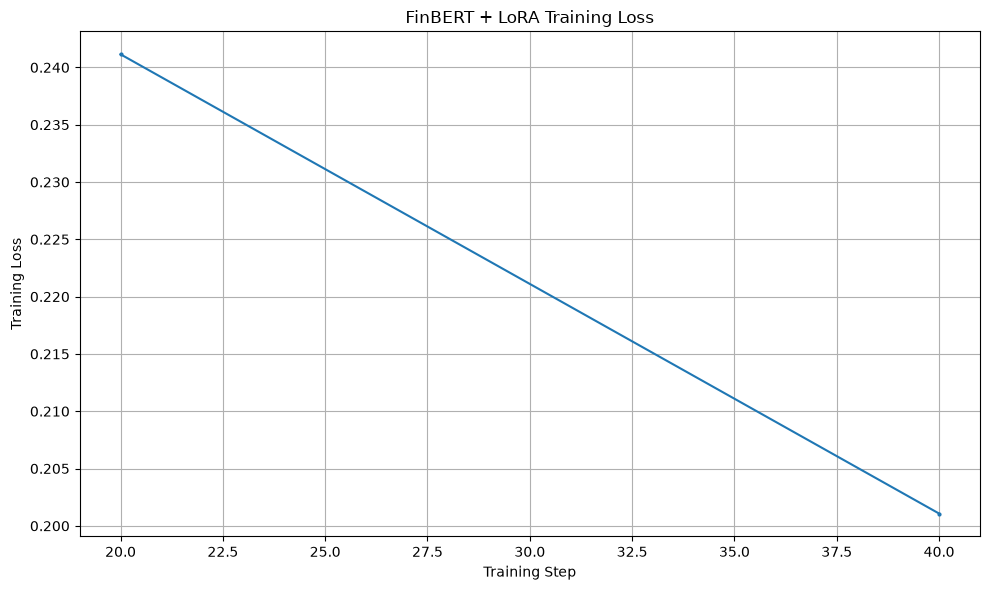

In [53]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = []
train_losses = []

for entry in log_history:
    if "loss" in entry and "step" in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_losses, marker="o", markersize=2)

plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("FinBERT + LoRA Training Loss")
plt.grid(True)

plt.tight_layout()

plt.savefig("training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [54]:
from sklearn.metrics import classification_report

# Get predictions from the trained LoRA model
predictions_output = trainer.predict(test_tokenized)

predictions = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

report = classification_report(
    true_labels,
    predictions,
    target_names=["negative", "neutral", "positive"],
    digits=4,
    zero_division=0
)

print(report)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,0.201074,0.362500,0.873711,0.842110,0.905935,0.867951


              precision    recall  f1-score   support

    negative     0.7869    0.9796    0.8727        49
     neutral     0.9554    0.8391    0.8935       230
    positive     0.7840    0.8991    0.8376       109

    accuracy                         0.8737       388
   macro avg     0.8421    0.9059    0.8680       388
weighted avg     0.8860    0.8737    0.8752       388



In [56]:
import json
from sklearn.metrics import classification_report

report_dict = classification_report(
    true_labels,
    predictions,
    target_names=["negative", "neutral", "positive"],
    output_dict=True,
    zero_division=0
)

with open("classification_report_lora.json", "w") as f:
    json.dump(report_dict, f, indent=4)

print(json.dumps(report_dict, indent=4))

{
    "negative": {
        "precision": 0.7868852459016393,
        "recall": 0.9795918367346939,
        "f1-score": 0.8727272727272727,
        "support": 49.0
    },
    "neutral": {
        "precision": 0.9554455445544554,
        "recall": 0.8391304347826087,
        "f1-score": 0.8935185185185185,
        "support": 230.0
    },
    "positive": {
        "precision": 0.784,
        "recall": 0.8990825688073395,
        "f1-score": 0.8376068376068376,
        "support": 109.0
    },
    "accuracy": 0.8737113402061856,
    "macro avg": {
        "precision": 0.842110263485365,
        "recall": 0.9059349467748806,
        "f1-score": 0.8679508762842096,
        "support": 388.0
    },
    "weighted avg": {
        "precision": 0.8859944646822295,
        "recall": 0.8737113402061856,
        "f1-score": 0.8751856724794869,
        "support": 388.0
    }
}


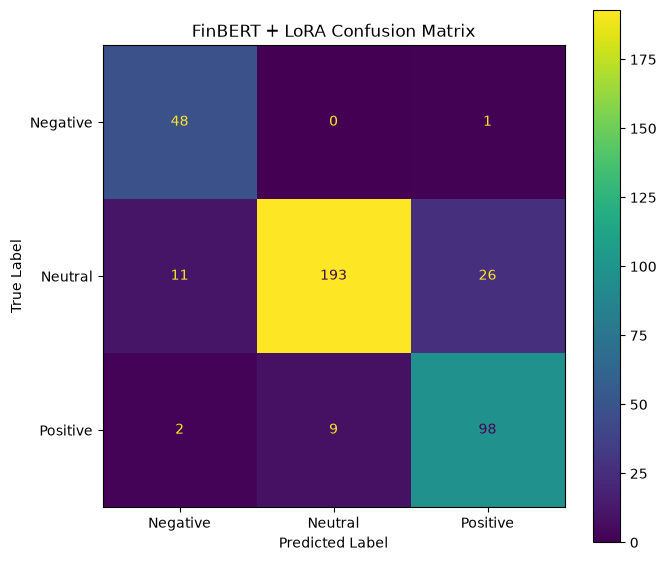

Confusion matrix saved as: confusion_matrix_lora.png

Confusion matrix values:
[[ 48   0   1]
 [ 11 193  26]
 [  2   9  98]]


In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix from the actual test predictions
cm = confusion_matrix(
    true_labels,
    predictions,
    labels=[0, 1, 2]
)

# Create the confusion matrix plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax)

plt.title("FinBERT + LoRA Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

# Save the image
plt.savefig(
    "confusion_matrix_lora.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved as: confusion_matrix_lora.png")
print("\nConfusion matrix values:")
print(cm)

In [58]:
import numpy as np

baseline_cm = np.array([
    [48, 0, 1],
    [12, 193, 25],
    [2, 10, 97]
])

lora_cm = np.array([
    [48, 0, 1],
    [11, 193, 26],
    [2, 9, 98]
])

print("Pretrained FinBERT:")
print(baseline_cm)

print("\nFinBERT + LoRA:")
print(lora_cm)

print("\nDifference (LoRA - Pretrained):")
print(lora_cm - baseline_cm)

Pretrained FinBERT:
[[ 48   0   1]
 [ 12 193  25]
 [  2  10  97]]

FinBERT + LoRA:
[[ 48   0   1]
 [ 11 193  26]
 [  2   9  98]]

Difference (LoRA - Pretrained):
[[ 0  0  0]
 [-1  0  1]
 [ 0 -1  1]]


In [59]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [60]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

prompt_model_name = "google/flan-t5-base"

prompt_tokenizer = AutoTokenizer.from_pretrained(prompt_model_name)

prompt_model = AutoModelForSeq2SeqLM.from_pretrained(
    prompt_model_name
).to(device)

prompt_model.eval()

print("Prompted LLM loaded successfully.")
print("Model:", prompt_model_name)
print("Device:", device)

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Prompted LLM loaded successfully.
Model: google/flan-t5-base
Device: cuda


In [61]:
test_sentence = test_df.iloc[0]["sentence"]

prompt = f"""
Classify the sentiment of this financial statement as exactly one of:
negative, neutral, positive.

Sentence: {test_sentence}

Answer with only one label.
"""

inputs = prompt_tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=256
).to(device)

with torch.no_grad():
    output = prompt_model.generate(
        **inputs,
        max_new_tokens=5
    )

prediction = prompt_tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print("Sentence:")
print(test_sentence)
print("\nModel output:")
print(prediction)

Sentence:
Revenue grew by 2 percent to  x20ac 580 million $ 743 million , from  x20ac 569 million .

Model output:
positive


In [63]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

prompt_predictions = []

for i, sentence in enumerate(test_df["sentence"]):
    prompt = f"""
Classify the sentiment of this financial statement as exactly one of:
negative, neutral, positive.

Sentence: {sentence}

Answer with only one label.
"""

    inputs = prompt_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        output = prompt_model.generate(
            **inputs,
            max_new_tokens=5
        )

    prediction = prompt_tokenizer.decode(
        output[0],
        skip_special_tokens=True
    ).strip().lower()

    prompt_predictions.append(prediction)

    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/388 samples")

Processed 50/388 samples
Processed 100/388 samples
Processed 150/388 samples
Processed 200/388 samples
Processed 250/388 samples
Processed 300/388 samples
Processed 350/388 samples


In [64]:
print("Predictions generated:", len(prompt_predictions))
print("Test samples:", len(test_df))

Predictions generated: 388
Test samples: 388


In [65]:
from collections import Counter

prediction_counts = Counter(prompt_predictions)

print("Unique model outputs:")
for label, count in prediction_counts.items():
    print(f"{label}: {count}")

valid_labels = {"negative", "neutral", "positive"}

invalid_predictions = [
    p for p in prompt_predictions
    if p not in valid_labels
]

print("\nInvalid predictions:", len(invalid_predictions))

if invalid_predictions:
    print("Examples of invalid outputs:")
    print(invalid_predictions[:10])

Unique model outputs:
positive: 273
negative: 112
neutral: 3

Invalid predictions: 0


In [66]:
true_labels_prompt = test_df["sentiment"].map(label2id).values
pred_labels_prompt = np.array([
    label2id[p] for p in prompt_predictions
])

prompt_results = {
    "model": "FLAN-T5-base zero-shot",
    "dataset": "Financial PhraseBank",
    "test_samples": len(test_df),
    "accuracy": accuracy_score(true_labels_prompt, pred_labels_prompt),
    "precision_macro": precision_score(
        true_labels_prompt,
        pred_labels_prompt,
        average="macro",
        zero_division=0
    ),
    "recall_macro": recall_score(
        true_labels_prompt,
        pred_labels_prompt,
        average="macro",
        zero_division=0
    ),
    "f1_macro": f1_score(
        true_labels_prompt,
        pred_labels_prompt,
        average="macro",
        zero_division=0
    )
}

print("Prompted LLM Results")
print("-" * 30)

for metric, value in prompt_results.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")

Prompted LLM Results
------------------------------
model: FLAN-T5-base zero-shot
dataset: Financial PhraseBank
test_samples: 388
accuracy: 0.3995
precision_macro: 0.6049
recall_macro: 0.6527
f1_macro: 0.3912


In [67]:
import json

with open("prompted_llm_results.json", "w") as f:
    json.dump(prompt_results, f, indent=4)

print("Saved: prompted_llm_results.json")

Saved: prompted_llm_results.json


In [68]:
with open("prompted_llm_results.json", "r") as f:
    print(f.read())

{
    "model": "FLAN-T5-base zero-shot",
    "dataset": "Financial PhraseBank",
    "test_samples": 388,
    "accuracy": 0.39948453608247425,
    "precision_macro": 0.6049297924297924,
    "recall_macro": 0.6526658689004122,
    "f1_macro": 0.39123791361403093
}


In [69]:
import pandas as pd

final_comparison = pd.DataFrame([
    {
        "Model": "FinBERT pretrained",
        "Accuracy": 0.8762886597938144,
        "Macro Precision": 0.8362583111457998,
        "Macro Recall": 0.9073842221371996,
        "Macro F1": 0.8641424414498404
    },
    {
        "Model": "FinBERT + LoRA",
        "Accuracy": 0.8737113402061856,
        "Macro Precision": 0.842110263485365,
        "Macro Recall": 0.9059349467748806,
        "Macro F1": 0.8679508762842096
    },
    {
        "Model": "FLAN-T5-base zero-shot",
        "Accuracy": 0.39948453608247425,
        "Macro Precision": 0.6049297924297924,
        "Macro Recall": 0.6526658689004122,
        "Macro F1": 0.39123791361403093
    }
])

print(final_comparison.to_string(index=False))

final_comparison.to_csv("final_model_comparison.csv", index=False)

with open("final_model_comparison.json", "w") as f:
    json.dump(final_comparison.to_dict(orient="records"), f, indent=4)

print("\nSaved:")
print("- final_model_comparison.csv")
print("- final_model_comparison.json")

                 Model  Accuracy  Macro Precision  Macro Recall  Macro F1
    FinBERT pretrained  0.876289         0.836258      0.907384  0.864142
        FinBERT + LoRA  0.873711         0.842110      0.905935  0.867951
FLAN-T5-base zero-shot  0.399485         0.604930      0.652666  0.391238

Saved:
- final_model_comparison.csv
- final_model_comparison.json


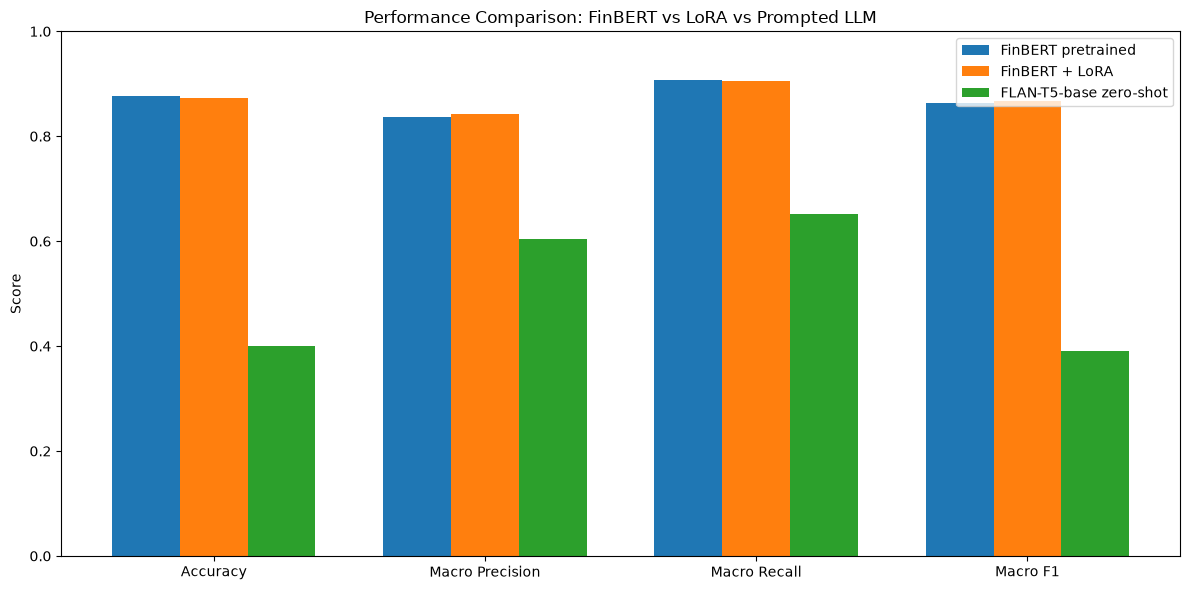

Saved: final_model_comparison.png


In [70]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

models = final_comparison["Model"].tolist()

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))

for i, model in enumerate(models):
    values = final_comparison.loc[
        final_comparison["Model"] == model,
        metrics
    ].values[0]

    plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=model
    )

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Performance Comparison: FinBERT vs LoRA vs Prompted LLM")
plt.legend()
plt.tight_layout()

plt.savefig("final_model_comparison.png", dpi=300)
plt.show()

print("Saved: final_model_comparison.png")

Prompted LLM Confusion Matrix:
[[ 49   0   0]
 [ 57   3 170]
 [  6   0 103]]


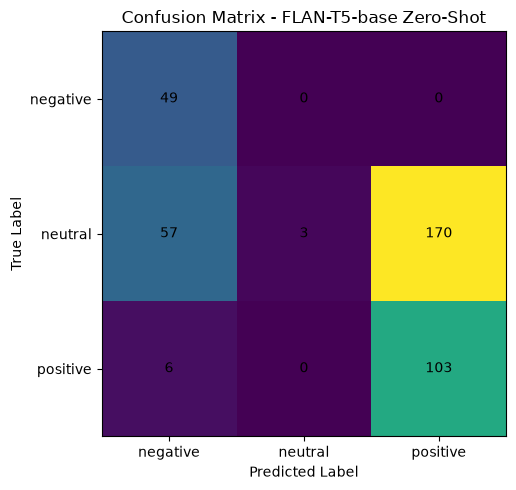

Saved: confusion_matrix_prompted_llm.png


In [71]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm_prompt = confusion_matrix(
    true_labels_prompt,
    pred_labels_prompt
)

print("Prompted LLM Confusion Matrix:")
print(cm_prompt)

plt.figure(figsize=(6, 5))
plt.imshow(cm_prompt)

plt.xticks([0, 1, 2], ["negative", "neutral", "positive"])
plt.yticks([0, 1, 2], ["negative", "neutral", "positive"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - FLAN-T5-base Zero-Shot")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm_prompt[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.savefig("confusion_matrix_prompted_llm.png", dpi=300)
plt.show()

print("Saved: confusion_matrix_prompted_llm.png")

In [72]:
from sklearn.metrics import classification_report

prompt_report = classification_report(
    true_labels_prompt,
    pred_labels_prompt,
    target_names=["negative", "neutral", "positive"],
    digits=4,
    zero_division=0
)

print(prompt_report)

              precision    recall  f1-score   support

    negative     0.4375    1.0000    0.6087        49
     neutral     1.0000    0.0130    0.0258       230
    positive     0.3773    0.9450    0.5393       109

    accuracy                         0.3995       388
   macro avg     0.6049    0.6527    0.3912       388
weighted avg     0.7540    0.3995    0.2436       388



In [73]:
prompt_report_dict = classification_report(
    true_labels_prompt,
    pred_labels_prompt,
    target_names=["negative", "neutral", "positive"],
    output_dict=True,
    zero_division=0
)

with open("classification_report_prompted_llm.json", "w") as f:
    json.dump(prompt_report_dict, f, indent=4)

print("Saved: classification_report_prompted_llm.json")

Saved: classification_report_prompted_llm.json


In [74]:
print("\nFINAL MODEL COMPARISON")
print("=" * 80)

for _, row in final_comparison.iterrows():
    print(f"\n{row['Model']}")
    print(f"  Accuracy:         {row['Accuracy']:.4f}")
    print(f"  Macro Precision:  {row['Macro Precision']:.4f}")
    print(f"  Macro Recall:     {row['Macro Recall']:.4f}")
    print(f"  Macro F1:         {row['Macro F1']:.4f}")


FINAL MODEL COMPARISON

FinBERT pretrained
  Accuracy:         0.8763
  Macro Precision:  0.8363
  Macro Recall:     0.9074
  Macro F1:         0.8641

FinBERT + LoRA
  Accuracy:         0.8737
  Macro Precision:  0.8421
  Macro Recall:     0.9059
  Macro F1:         0.8680

FLAN-T5-base zero-shot
  Accuracy:         0.3995
  Macro Precision:  0.6049
  Macro Recall:     0.6527
  Macro F1:         0.3912


In [75]:
lora_model.save_pretrained("./finbert-lora-final")
prompt_tokenizer.save_pretrained("./finbert-lora-final")

print("LoRA model saved successfully.")

LoRA model saved successfully.


In [76]:
import os

print("Files in finbert-lora-final:")
for file in os.listdir("./finbert-lora-final"):
    print("-", file)

Files in finbert-lora-final:
- README.md
- tokenizer_config.json
- tokenizer.json
- adapter_model.safetensors
- adapter_config.json
